# Intelligent Diabetes Risk Prediction System
## 01 - Data Exploration

### Purpose
This notebook performs the initial exploration of the Diabetes Prediction Dataset. The aim is to understand the dataset structure, assess data quality, explore feature and target distributions, and identify preprocessing requirements before machine learning model development.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Load the Dataset

In [ ]:
df = pd.read_csv("../data/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Dataset Structure

In [35]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 9


In [36]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


### Initial Observation
The dataset contains both numerical and categorical variables. Categorical variables such as gender and smoking history will require appropriate encoding before most machine learning algorithms can use them.

## 3. Descriptive Statistics

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


## 4. Data Quality Assessment
### 4.1 Missing Values

In [39]:
missing_values = df.isnull().sum()
missing_values

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [40]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### Observation
The output above identifies any explicit missing values. The `No Info` category in smoking history should also be investigated separately because it may represent unavailable information rather than a standard smoking category.

### 4.2 Duplicate Records

In [41]:
duplicate_count = df.duplicated().sum()
print("Number of potential duplicate rows:", duplicate_count)

Number of potential duplicate rows: 3854


### Observation
Because the dataset does not contain a unique patient identifier, identical rows cannot automatically be assumed to represent duplicate patients. Their treatment should be justified during preprocessing.

## 5. Categorical Feature Analysis
### 5.1 Gender

In [42]:
df["gender"].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [43]:
df["gender"].value_counts(normalize=True) * 100

gender
Female    58.552
Male      41.430
Other      0.018
Name: proportion, dtype: float64

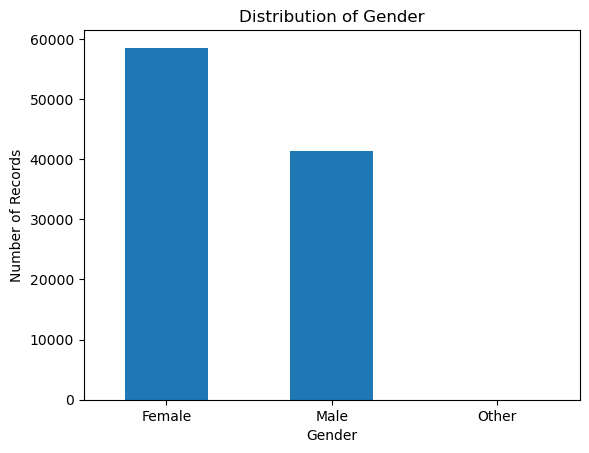

In [44]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

### 5.2 Smoking History

In [45]:
df["smoking_history"].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [46]:
df["smoking_history"].value_counts(normalize=True) * 100

smoking_history
No Info        35.816
never          35.095
former          9.352
current         9.286
not current     6.447
ever            4.004
Name: proportion, dtype: float64

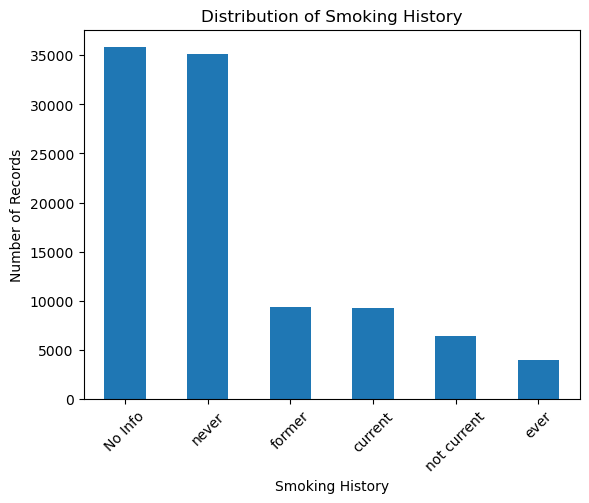

In [47]:
df["smoking_history"].value_counts().plot(kind="bar")
plt.title("Distribution of Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

### Observation
Smoking history contains several categories, including `No Info`. Its frequency and meaning should be considered during preprocessing.

## 6. Target Variable Analysis

In [48]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [49]:
target_percentage = df["diabetes"].value_counts(normalize=True) * 100
target_percentage

diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

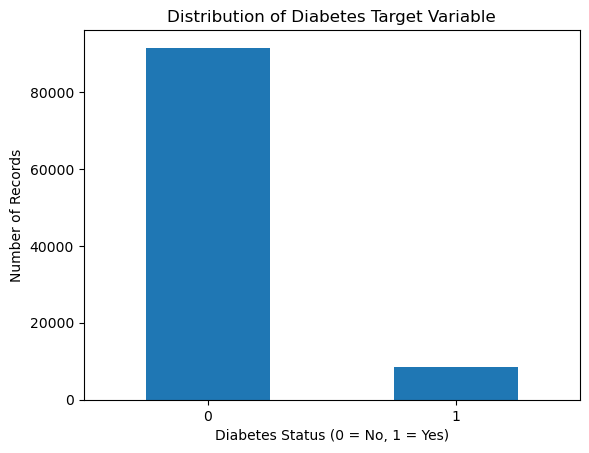

In [50]:
df["diabetes"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Diabetes Target Variable")
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

### Observation
If the output confirms substantial class imbalance, accuracy alone may be misleading. Precision, recall, F1-score and ROC-AUC should also be considered during model evaluation.

## Next Steps
- Analyse age, BMI, HbA1c and blood glucose distributions
- Analyse hypertension and heart disease
- Explore relationships between features and diabetes
- Examine correlations and potential outliers
- Define the preprocessing strategy

## 7. Numerical Feature Analysis

### Age

In [51]:
df["age"].describe()

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

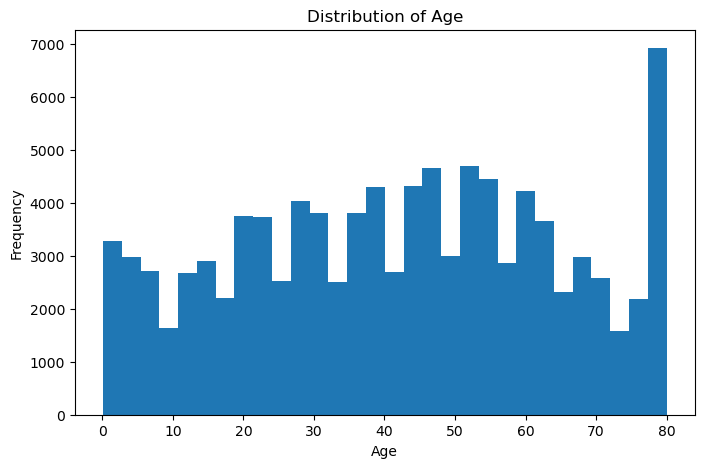

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=30)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### BMI

In [53]:
df["bmi"].describe()

count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64

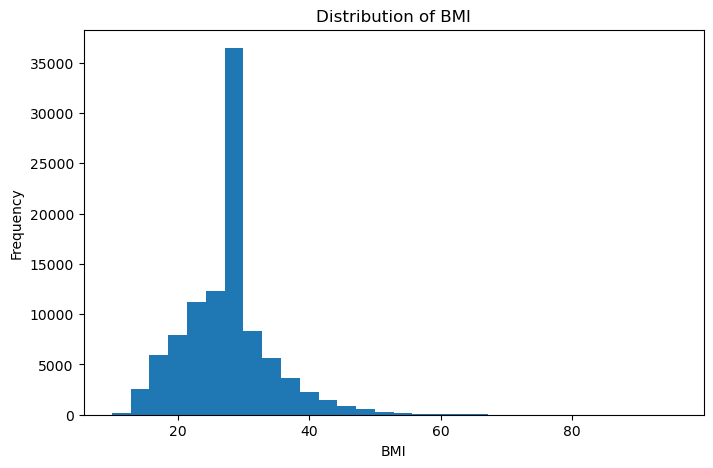

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(df["bmi"], bins=30)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

### HbA1c Level

In [55]:
df["HbA1c_level"].describe()

count    100000.000000
mean          5.527507
std           1.070672
min           3.500000
25%           4.800000
50%           5.800000
75%           6.200000
max           9.000000
Name: HbA1c_level, dtype: float64

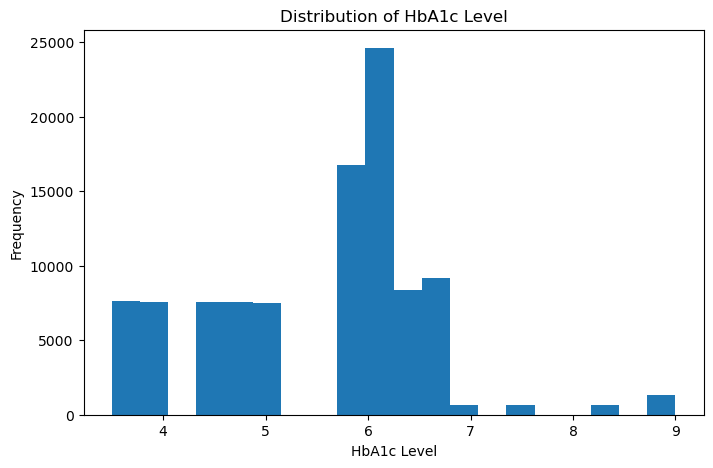

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(df["HbA1c_level"], bins=20)

plt.title("Distribution of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")
plt.show()

### Blood Glucose Level

In [57]:
df["blood_glucose_level"].describe()

count    100000.000000
mean        138.058060
std          40.708136
min          80.000000
25%         100.000000
50%         140.000000
75%         159.000000
max         300.000000
Name: blood_glucose_level, dtype: float64

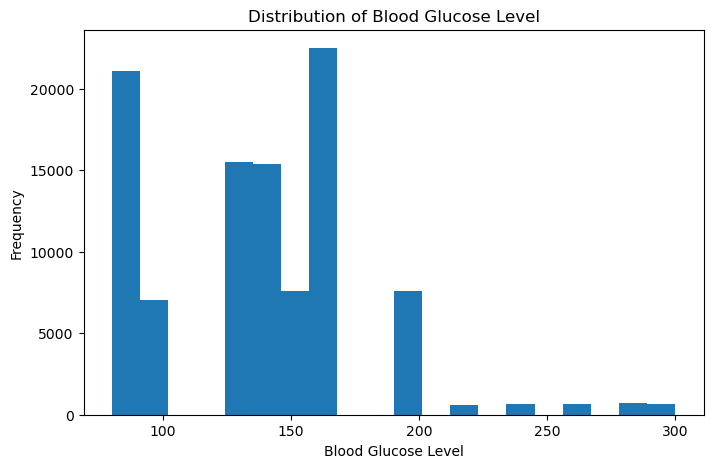

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(df["blood_glucose_level"], bins=20)

plt.title("Distribution of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.show()

## 8. Binary Health Features

### Hypertension

In [59]:
df["hypertension"].value_counts()

hypertension
0    92515
1     7485
Name: count, dtype: int64

In [60]:
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0    92.515
1     7.485
Name: proportion, dtype: float64

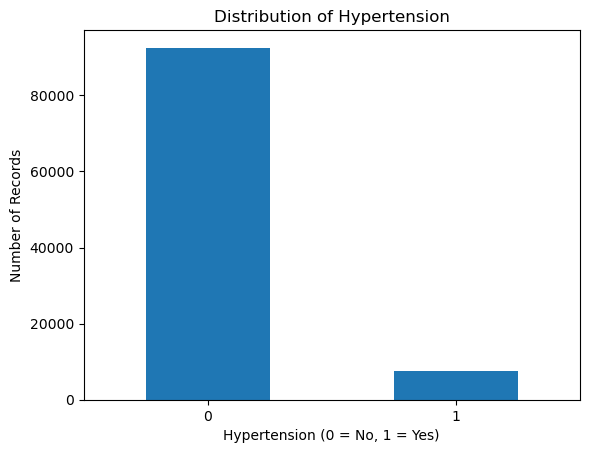

In [32]:
df["hypertension"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

### Heart Disease

In [61]:
df["heart_disease"].value_counts()

heart_disease
0    96058
1     3942
Name: count, dtype: int64

In [62]:
df["heart_disease"].value_counts(normalize=True) * 100

heart_disease
0    96.058
1     3.942
Name: proportion, dtype: float64

## 9. Relationship Between Features and Diabetes

In [63]:
numerical_features = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

df.groupby("diabetes")[numerical_features].mean()

,age,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,
0,40.115187,26.887163,5.396761,132.852470
1,60.946588,31.988382,6.934953,194.094706


## 10. Diabetes Rate by Hypertension

In [64]:
pd.crosstab(
    df["hypertension"],
    df["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
hypertension,,
0,93.069232,6.930768
1,72.104208,27.895792


Also for heart disease.

In [65]:
pd.crosstab(
    df["heart_disease"],
    df["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
heart_disease,,
0,92.470174,7.529826
1,67.858955,32.141045


## 11. Diabetes Rate by Gender

In [66]:
pd.crosstab(
    df["gender"],
    df["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
gender,,
Female,92.381131,7.618869
Male,90.251026,9.748974
Other,100.000000,0.000000


Also smoking history.

In [67]:
pd.crosstab(
    df["smoking_history"],
    df["diabetes"],
    normalize="index"
) * 100

diabetes,0,1
smoking_history,,
No Info,95.940362,4.059638
current,89.791083,10.208917
ever,88.211788,11.788212
former,82.998289,17.001711
never,90.465878,9.534122
not current,89.297348,10.702652


## 12. Correlation Analysis

In [68]:
numeric_df = df.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

correlation_matrix

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


In [69]:
correlation_matrix["diabetes"].sort_values(ascending=False)

diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
Name: diabetes, dtype: float64

## 13. Check Potential Outliers

### BMI

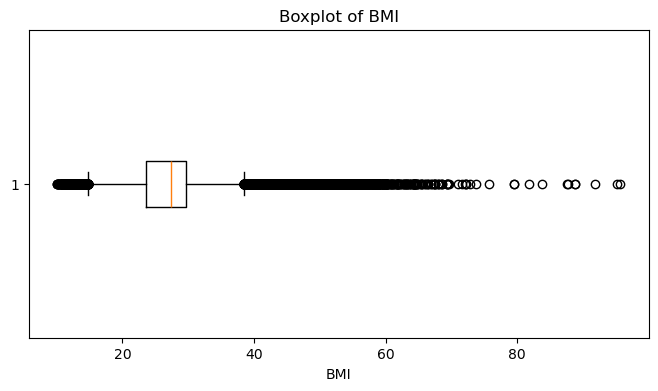

In [70]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["bmi"], vert=False)

plt.title("Boxplot of BMI")
plt.xlabel("BMI")
plt.show()

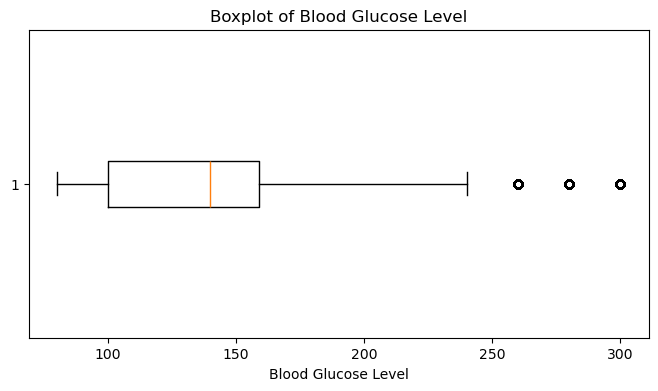

In [71]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["blood_glucose_level"], vert=False)

plt.title("Boxplot of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.show()

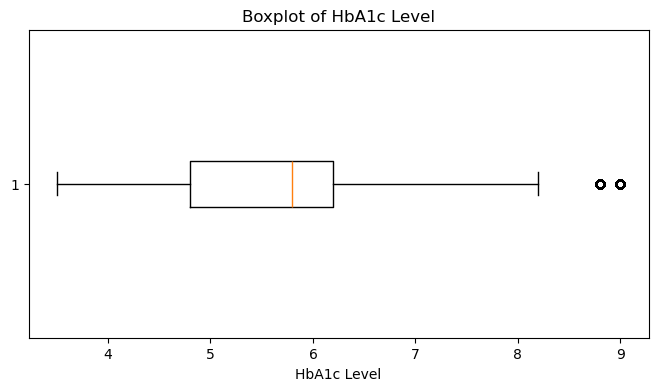

In [72]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["HbA1c_level"], vert=False)

plt.title("Boxplot of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.show()

## 14. Initial EDA Findings

The exploratory data analysis identified several important patterns in the dataset:

- The dataset contains 100,000 observations and includes demographic, lifestyle and clinical features that may be useful for predicting diabetes.

- Age ranges from 0.08 to 80 years, with an average age of approximately 41.9 years.

- BMI has an average of approximately 27.3. The distribution is right-skewed and several potential extreme values are present, with a maximum BMI of 95.69.

- HbA1c levels range from 3.5 to 9.0, with an average of approximately 5.53.

- Blood glucose levels range from 80 to 300, with an average of approximately 138.1.

- Individuals with diabetes show noticeably higher average values for several features. The diabetic group has an average age of approximately 60.9 years compared with 40.1 years for the non-diabetic group. Average BMI is approximately 32.0 compared with 26.9, average HbA1c is approximately 6.93 compared with 5.40, and average blood glucose is approximately 194.1 compared with 132.9.

- Hypertension appears to be associated with diabetes in this dataset. Approximately 27.9% of individuals with hypertension have diabetes compared with approximately 6.9% of individuals without hypertension.

- Heart disease also shows an association with diabetes. Approximately 32.1% of individuals with heart disease have diabetes compared with approximately 7.5% of individuals without heart disease.

- The diabetes rate is approximately 9.75% for males and 7.62% for females. The "Other" gender category contains very few observations, so its 0% diabetes rate should not be interpreted as strong evidence of a relationship.

- Diabetes rates vary across smoking-history categories. Former smokers have the highest observed diabetes rate at approximately 17.0%, while the "No Info" category has the lowest rate at approximately 4.1%. These differences represent associations within this dataset and should not be interpreted as causal relationships.

- Among the numerical variables, blood glucose level has the strongest positive correlation with diabetes (approximately 0.420), followed by HbA1c level (0.401), age (0.258), BMI (0.214), hypertension (0.198), and heart disease (0.172).

- The boxplots identify potential extreme values in BMI, blood glucose level and HbA1c level. These observations should not automatically be removed because unusually high clinical measurements may represent valid patient records.

Overall, the exploratory analysis suggests that blood glucose level, HbA1c level, age, BMI, hypertension and heart disease may provide useful predictive information for the diabetes classification model. Further preprocessing and machine learning analysis will be required to determine their predictive importance.